In [125]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

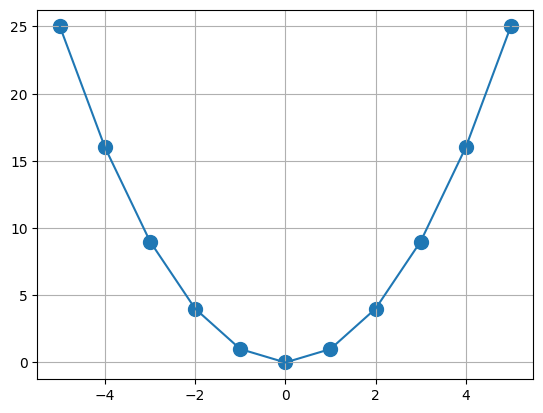

In [126]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([-5,-4,-3,-2,-1,0,1,2,3,4,5])

y = np.array([25,16,9,4,1,0,1,4,9,16,25])

plt.scatter(X, y, s=100)
plt.plot(X, y)
plt.grid(True)
plt.show()

## In such cases polynomial regression is used

- $\text{In case of simple linear regression we have y= }\beta_0+\beta X_1  \text{ this was in the  case of simple linear regression}$

- $\text{in the polynomial linear regression we like in this case we have } \beta_0X^0,\beta_1X^1,\beta_2X^2$

-  $\textbf{degree is the hyperparameter and if the degree is too large then it is there may be overfitting and if it is too less then it may be underfitting}$

- $\textbf{in this we add the extra column of } X^0\quad X^1 \quad X^2 \textbf{After this we train the model}$

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor,LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

### Generating the datasets

In [128]:
X = 6*np.random.randn(400,1)-3

y = 0.8*X**2+0.9*X+2+15*np.random.randn(400,1)
y 

array([[ -4.20728888],
       [-32.71196048],
       [ -7.68192872],
       [ 38.00532928],
       [ -4.42942472],
       [121.81629268],
       [ 13.75652867],
       [ -7.28438879],
       [  6.63291334],
       [  5.80865317],
       [ 38.56951244],
       [  1.88264926],
       [ 54.82210894],
       [  9.40961039],
       [ 72.61795056],
       [ 24.20640316],
       [ 52.07529683],
       [ -3.41813925],
       [-13.31757243],
       [ 39.77529618],
       [ -2.02908575],
       [ 69.96388567],
       [ 10.855646  ],
       [ 32.61202739],
       [ 71.11354752],
       [ 35.05716233],
       [156.58402068],
       [  7.51844874],
       [ 10.47635836],
       [ 63.53880617],
       [ 64.61497419],
       [  2.49392921],
       [ -8.83238959],
       [  5.50534046],
       [160.32835728],
       [ 34.69248191],
       [ -5.74824693],
       [ 33.44355708],
       [  1.83848309],
       [  1.17852706],
       [  0.6965209 ],
       [  7.40130602],
       [120.35571893],
       [ -1

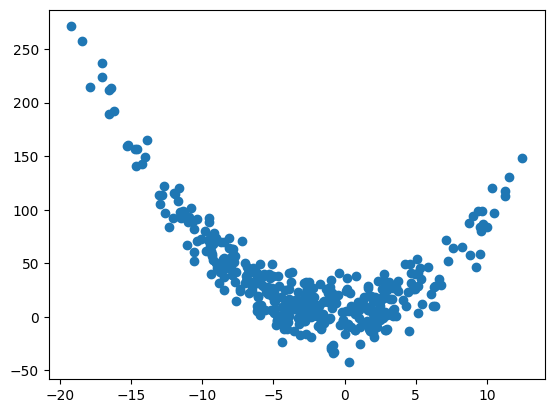

In [129]:
plt.scatter(X,y,)

In [130]:
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

## we will check how the linear regression model will perform in this case 

In [131]:
lr = LinearRegression()
lr.fit(X_train,y_train)
out = lr.predict(X_test)


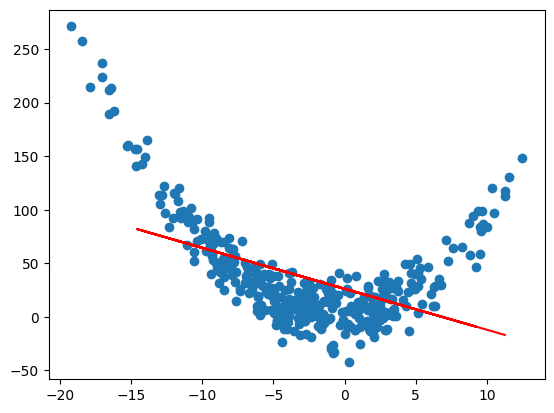

In [132]:
plt.scatter(X,y)
plt.plot(X_test,out,color= 'red')
plt.show()

In [133]:
print(r2_score(y_test,out))

0.1916824098981652


## Uisng the polynomial transformation  class

In [134]:
poly = PolynomialFeatures(degree=2)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [135]:
(X_train_trans[0])

array([ 1.        ,  9.62586322, 92.65724276])

In [136]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)
out = lr.predict(X_test_trans)
print(r2_score(y_test,out))

0.824679225622508


In [137]:
X_train.shape

(320, 1)

In [138]:
X_train_trans.shape

(320, 3)

In [139]:
y_train.shape

(320, 1)

In [140]:
lr.intercept_

array([3.12002095])

In [141]:
lr.coef_

array([[0.        , 0.97022516, 0.78877237]])

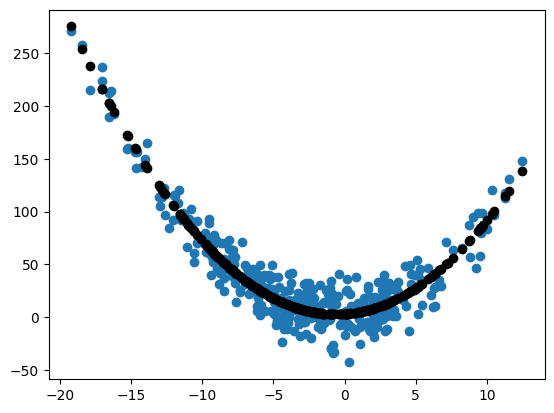

In [142]:
plt.scatter(X,y)
out = lr.predict(X_train_trans)
plt.scatter(X_train,out,color ='black')

### 3D Polynomial regression

In [143]:
x = 7*np.random.rand(100,1)-2.8
y = 7*np.random.rand(100,1)-2.8
z = x**2+y**2+0.2*x+0.2*y+0.1*x*y+np.random.rand(100,1)


In [144]:
print(x.shape)
print(y.shape)
print(z.shape)

(100, 1)
(100, 1)
(100, 1)


In [145]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel(),opacity=0.96)
fig.show()

## Checking the output with the 

In [146]:
(np.array([x,y])).reshape

<function ndarray.reshape(*shape, order='C', copy=None)>

In [147]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)
x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)
xGrid,yGrid = np.meshgrid(x_input,y_input)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final =lr.predict(final).reshape(10,10)




In [148]:
import plotly.graph_objects as go
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()

## Training the polynomial regression model now

In [149]:
X_multi = np.array([x,y]).reshape(100,2)

In [150]:
X_multi.shape

(100, 2)

In [154]:
ploy=PolynomialFeatures(degree=2)
X_multi_trans=poly.fit_transform(X_multi)

In [153]:
print("Input",poly.n_features_in_)
print("output",poly.n_output_features_)
print("power",poly.powers_)

Input 2
output 6
power [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [155]:
X_multi_trans.shape

(100, 6)

In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)
z_final=lr.predict(X_multi_trans).reshape(10,10)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [159]:
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()
